# Partie 3 - Représentation des données

On repart des données déjà nettoyées dans le notebook précédent pour les transformer en vecteurs numériques, seule forme que les modèles de machine learning peuvent utiliser.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from text_cleaning import clean_text

df = pd.read_csv("../data/raw/tweets_suspect.csv")
df = df.dropna(subset=["message", "label"]).drop_duplicates(subset=["message"])
df["clean_text"] = df["message"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0]

print(df.shape)


(59416, 3)


## Pourquoi le TF-IDF

Le sujet propose plusieurs façons de transformer le texte en nombres, des approches simples comme Bag of Words ou TF-IDF, et des approches plus avancées comme Word2Vec ou BERT. On a choisi le **TF-IDF** pour plusieurs raisons :

- Les tweets sont courts, donc pas besoin d'une représentation très complexe pour capturer le sens général.
- TF-IDF ne se contente pas de compter les mots comme le Bag of Words classique : il diminue le poids des mots qui reviennent dans presque tous les tweets, et augmente celui des mots plus spécifiques, ce qui aide à mieux distinguer les tweets suspects des autres.
- C'est rapide à calculer et facile à comprendre, contrairement à des embeddings comme BERT qui demandent beaucoup plus de ressources et de temps d'entraînement.
- C'est une bonne base de départ : si les résultats ne sont pas satisfaisants, on pourra toujours essayer une méthode plus avancée ensuite.

On a laissé la possibilité d'utiliser des bigrammes en plus des mots seuls (paramètre `ngram_max` dans `params.yaml`), pour capturer un peu de contexte (par exemple "not good" est différent de "good").

In [2]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df["clean_text"])

print("nombre de tweets :", X.shape[0])
print("taille du vocabulaire :", X.shape[1])


nombre de tweets : 59416
taille du vocabulaire : 20000


## Un exemple concret

Pour voir ce que fait le TF-IDF, on regarde les mots avec le score le plus élevé pour quelques tweets.

In [3]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

for i in range(3):
    row = X[i].toarray().flatten()
    top_idx = row.argsort()[-5:][::-1]
    mots_importants = [feature_names[j] for j in top_idx if row[j] > 0]
    print("tweet :", df["clean_text"].iloc[i])
    print("mots les plus importants selon TF-IDF :", mots_importants)
    print("-" * 60)


tweet : awww bummer shoulda got david carr third day
mots les plus importants selon TF-IDF : ['carr', 'shoulda', 'third', 'david', 'bummer']
------------------------------------------------------------
tweet : upset update facebook texting might cry result school today also blah
mots les plus importants selon TF-IDF : ['today also', 'update facebook', 'texting', 'school today', 'blah']
------------------------------------------------------------
tweet : dived many time ball managed save rest go bound
mots les plus importants selon TF-IDF : ['bound', 'many time', 'managed', 'ball', 'save']
------------------------------------------------------------


## Ce qu'on retient

Le TF-IDF transforme chaque tweet en un vecteur de plusieurs milliers de dimensions (une par mot ou paire de mots du vocabulaire), où chaque valeur représente l'importance du mot dans ce tweet par rapport à l'ensemble des tweets. C'est cette représentation qui sert d'entrée aux modèles entraînés dans `src/train.py` et qui sera reprise dans la partie suivante pour comparer plusieurs algorithmes de classification.

# Partie 4 - Construction des modèles

On sépare les données en train/test (même split que dans le pipeline, test_size=0.2 et random_state=42 pour rester cohérent avec `src/preprocess.py`), puis on compare plusieurs modèles de classification.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

print("train :", X_train.shape[0], "| test :", X_test.shape[0])


train : 47532 | test : 11884


## Gestion du déséquilibre des classes

On a vu dans l'exploration que les classes sont très déséquilibrées (environ 90% / 10%). On utilise la stratégie **class weight** : ça veut dire qu'on dit au modèle de donner plus d'importance aux erreurs faites sur la classe minoritaire (les tweets suspects), pour qu'il n'ait pas juste tendance à toujours prédire la classe majoritaire. C'est la stratégie la plus simple à mettre en place (pas besoin de générer de nouvelles données comme avec SMOTE) et elle est directement disponible dans scikit-learn via le paramètre `class_weight="balanced"`.

## Comparaison de trois modèles

On compare trois algorithmes différents parmi ceux proposés par le sujet : **Logistic Regression**, **Random Forest** et **Naive Bayes**. Les deux premiers sont les mêmes que ceux vus en cours (avec en plus Decision Tree qui n'est pas proposé dans ce sujet), et Naive Bayes est le modèle de base classique pour la classification de texte.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultats = []

modeles = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Naive Bayes": MultinomialNB(),
}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    resultats.append({
        "modele": nom,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
    })
    print(nom, "termine")


Logistic Regression termine


Random Forest termine
Naive Bayes termine


Naive Bayes ne prend pas le paramètre `class_weight` (ce n'est pas prévu pour ce type de modèle), donc pour lui on laisse le déséquilibre tel quel, seulement à titre de comparaison.

In [6]:
import pandas as pd

tableau_resultats = pd.DataFrame(resultats).set_index("modele")
tableau_resultats


,accuracy,precision,recall,f1_score
modele,,,,
Logistic Regression,0.975682,0.980091,0.993057,0.986531
Random Forest,0.983087,0.985334,0.995965,0.990621
Naive Bayes,0.915853,0.914222,1.000000,0.955189


## Ce qu'on retient

Les trois modèles donnent des résultats assez proches en accuracy globale, ce qui n'est pas surprenant vu le déséquilibre des classes (prédire toujours la classe majoritaire donnerait déjà une bonne accuracy). Ce qui compte vraiment ici, c'est le recall et le F1-score sur la classe suspecte, puisque c'est elle qu'on cherche à détecter. Le modèle avec le meilleur compromis entre les deux sera repris comme modèle final dans le pipeline DVC (`params.yaml`).

# Partie 5 - Entraînement et validation

Le split train/test qu'on a utilisé jusqu'ici donne un seul résultat, qui peut varier un peu selon la façon dont les données ont été coupées. Pour avoir une idée plus fiable des performances, on utilise une **validation croisée** (cross-validation) : on découpe les données d'entraînement en 5 morceaux (5-fold), et on entraîne/teste le modèle 5 fois en changeant à chaque fois le morceau utilisé comme test. On obtient ainsi une moyenne plus fiable qu'un seul split.

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1"]

resultats_cv = []

for nom, modele in modeles.items():
    scores = cross_validate(modele, X_train, y_train, cv=cv, scoring=scoring)
    resultats_cv.append({
        "modele": nom,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1_score": scores["test_f1"].mean(),
    })
    print(nom, "termine")


Logistic Regression termine


Random Forest termine


Naive Bayes termine


In [8]:
tableau_cv = pd.DataFrame(resultats_cv).set_index("modele")
tableau_cv


,accuracy,precision,recall,f1_score
modele,,,,
Logistic Regression,0.972503,0.977954,0.991696,0.984777
Random Forest,0.980834,0.984351,0.994440,0.989369
Naive Bayes,0.910986,0.909778,0.999906,0.952715


## Ce qu'on retient

Les résultats de la validation croisée sont très proches de ceux obtenus avec le simple split train/test plus haut, ce qui est plutôt rassurant : ça veut dire que les performances ne dépendent pas trop de la façon dont les données ont été séparées, et que le modèle généralise bien.

# Partie 6 - Évaluation et optimisation

Random Forest est le modèle qui donne les meilleurs résultats dans les parties précédentes. On regarde maintenant plus en détail ses erreurs avec une matrice de confusion et une courbe ROC.

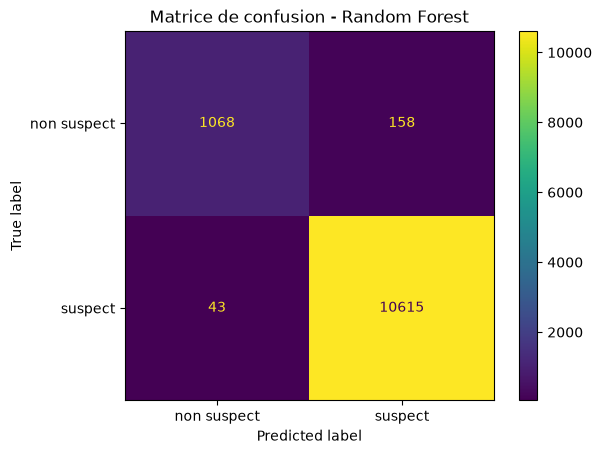

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
import matplotlib.pyplot as plt

rf = modeles["Random Forest"]
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=["non suspect", "suspect"])
plt.title("Matrice de confusion - Random Forest")
plt.show()


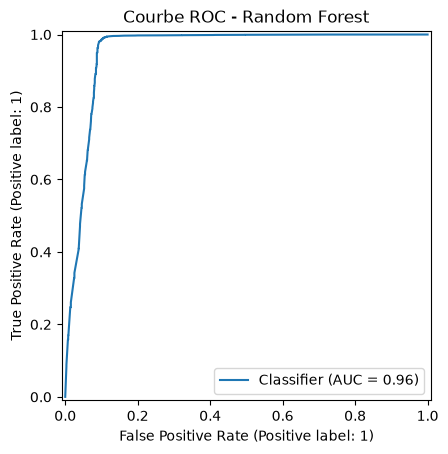

AUC : 0.9550675656025986


In [10]:
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Courbe ROC - Random Forest")
plt.show()

print("AUC :", roc_auc_score(y_test, y_proba_rf))


## Recherche d'hyperparamètres

On utilise `GridSearchCV` pour tester plusieurs combinaisons du nombre d'arbres (`n_estimators`) et de la profondeur maximale (`max_depth`), avec la même validation croisée à 5 blocs qu'avant. On optimise sur le F1-score plutôt que l'accuracy, parce que c'est la métrique qui reflète le mieux la capacité du modèle à bien détecter les tweets suspects malgré le déséquilibre des classes.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 20, 40],
}

rf_base = RandomForestClassifier(class_weight="balanced", random_state=42)

grid_search = GridSearchCV(rf_base, param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("meilleurs paramètres :", grid_search.best_params_)
print("meilleur f1-score (cv) :", grid_search.best_score_)


meilleurs paramètres : {'max_depth': None, 'n_estimators': 200}
meilleur f1-score (cv) : 0.9893693089643432


In [12]:
meilleur_rf = grid_search.best_estimator_
y_pred_best = meilleur_rf.predict(X_test)

print("accuracy :", accuracy_score(y_test, y_pred_best))
print("précision :", precision_score(y_test, y_pred_best))
print("recall :", recall_score(y_test, y_pred_best))
print("f1_score :", f1_score(y_test, y_pred_best))


accuracy : 0.9830865028609895
précision : 0.9853337046319502
recall : 0.9959654719459561
f1_score : 0.9906210629461994


## Ce qu'on retient

La recherche d'hyperparamètres permet de confirmer (ou d'ajuster un peu) la configuration du Random Forest. Les paramètres trouvés ici seront repris dans `params.yaml` pour que le pipeline DVC utilise cette configuration comme modèle final.